# Decision Tree

## Overview

A **Decision Tree** is a supervised learning algorithm that learns a hierarchical series of binary rules to partition the feature space into regions, each associated with a prediction. It is one of the most interpretable machine learning models — predictions can be traced through a sequence of human-readable if-then conditions.

Decision Trees are the building blocks of powerful ensemble methods like **Random Forests** and **Gradient Boosting**.

---

## How It Works

The tree is built by **recursive binary splitting**. At each node, the algorithm searches over all features and thresholds to find the split that best separates the data according to an impurity measure. This process continues until a stopping criterion is met (maximum depth, minimum samples, or pure leaves).

$$\text{Information Gain} = H(\text{parent}) - \left[\frac{n_L}{n} H(\text{left}) + \frac{n_R}{n} H(\text{right})\right]$$

The split that maximises information gain is selected.

---

## Impurity Measures

### Shannon Entropy

$$H(y) = -\sum_{k} p_k \log_2 p_k$$

Measures the average uncertainty in the label distribution. A pure node (all one class) has entropy 0.

### Gini Impurity

$$G(y) = 1 - \sum_{k} p_k^2$$

Measures the probability of misclassifying a randomly chosen sample. Computationally slightly cheaper than entropy and often produces similar results.

### Variance Reduction (Regression)

$$\text{Gain} = \text{Var}(y) - \left[\frac{n_L}{n}\text{Var}(y_L) + \frac{n_R}{n}\text{Var}(y_R)\right]$$

For regression tasks, the split that most reduces variance is chosen.

---

## Stopping Criteria

The tree stops growing a branch when any of the following are met:

| Criterion | Description |
|---|---|
| `max_depth` | Tree has reached the maximum allowed depth |
| `min_samples_split` | Node has fewer samples than the minimum to split |
| Pure node | All samples at the node belong to the same class |
| No gain | No split produces positive information gain |

---

## Feature Importance

The importance of feature $j$ is the total weighted impurity reduction across all nodes that split on $j$:

$$\text{Importance}(j) = \sum_{t : \text{split on } j} n_t \cdot \Delta H_t$$

Importances are normalized to sum to 1, giving a relative ranking of feature contributions.

---

## Bias-Variance Tradeoff

| Setting | Bias | Variance |
|---|---|---|
| Deep tree (large `max_depth`) | Low | High — prone to overfitting |
| Shallow tree (small `max_depth`) | High | Low — prone to underfitting |

Pruning via `max_depth` and `min_samples_split` is the primary regularization strategy.

 EXPERIMENT 1 — Effect of max_depth (Moons)


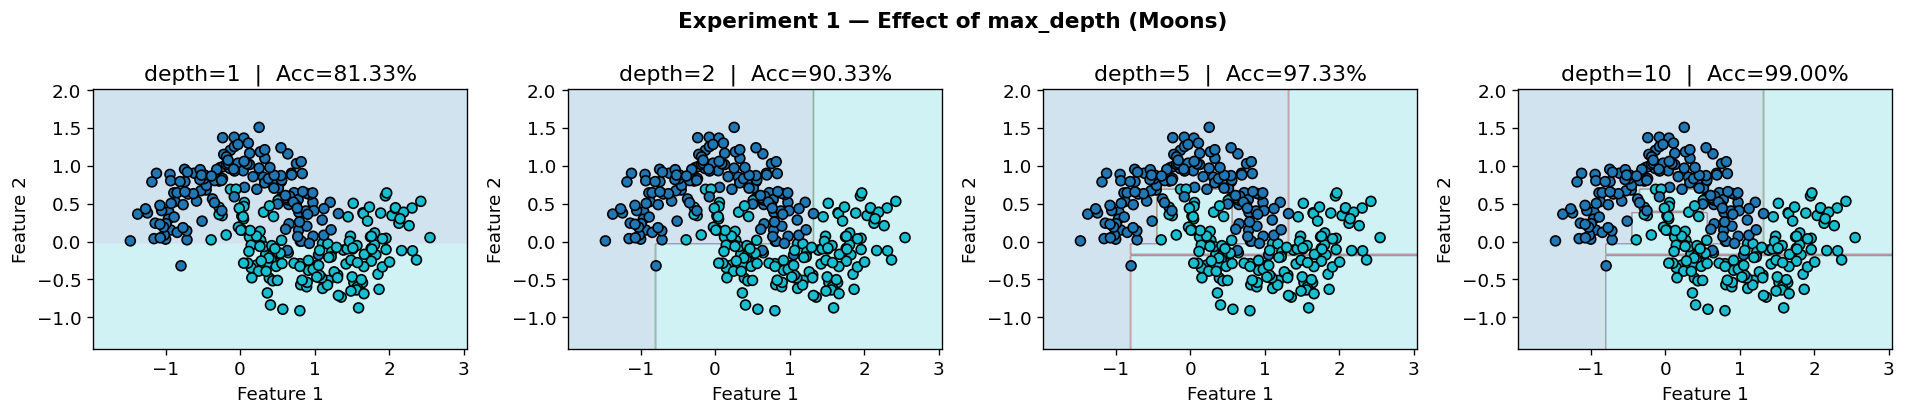

 EXPERIMENT 2 — Entropy vs Gini Criterion


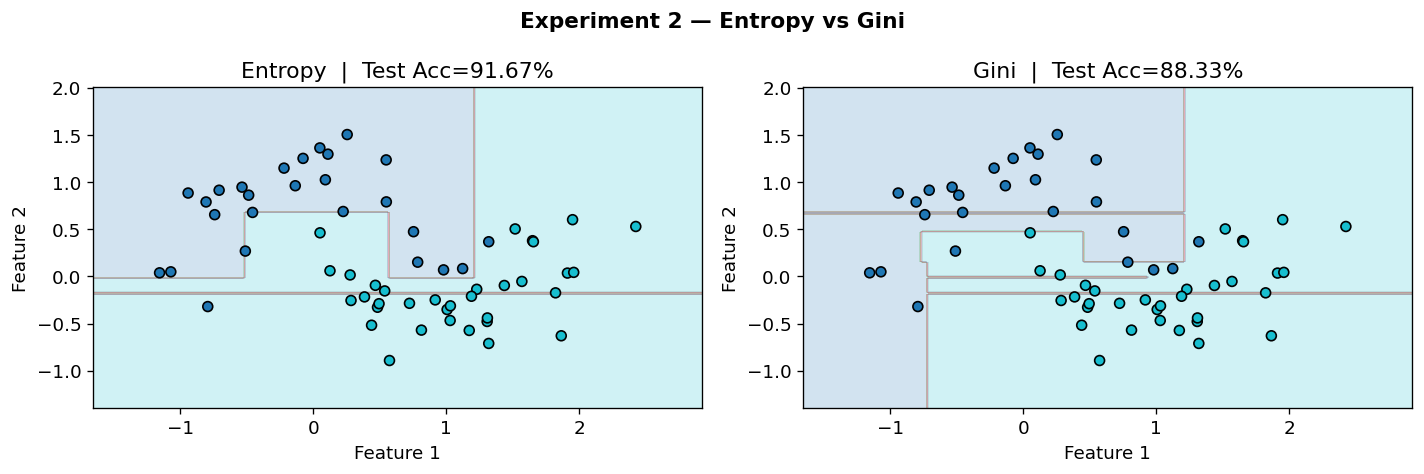

 EXPERIMENT 3 — Overfitting Analysis


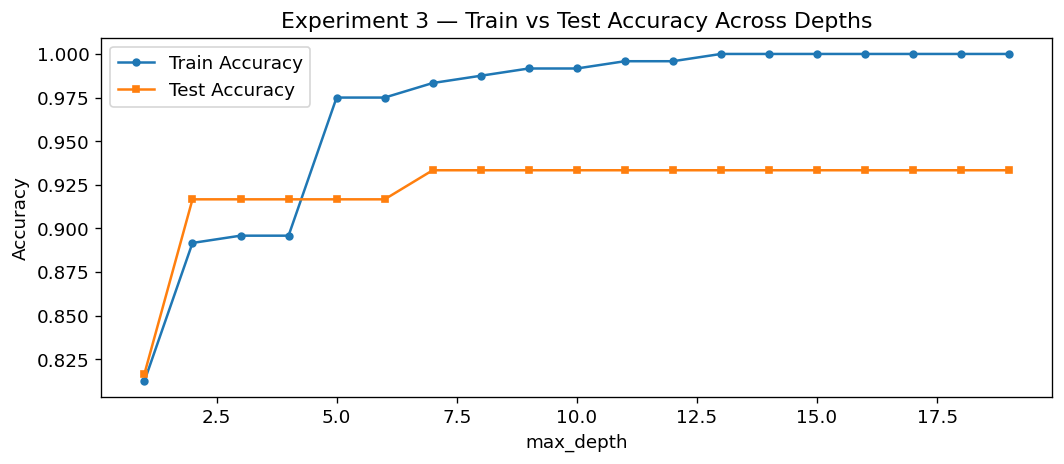

Best depth: 7  |  Test Accuracy: 93.33%

 EXPERIMENT 4 — Iris Dataset & Feature Importances
Test Accuracy : 93.33%

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



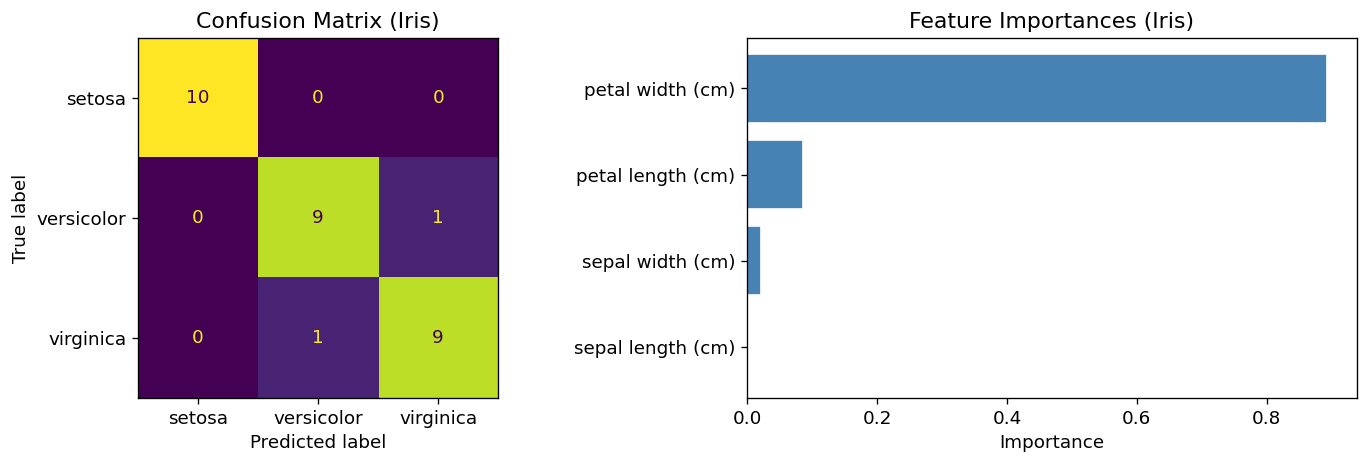

 EXPERIMENT 5 — Breast Cancer Dataset
Test Accuracy : 92.11%

              precision    recall  f1-score   support

   malignant       0.85      0.95      0.90        42
      benign       0.97      0.90      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.93      0.92       114
weighted avg       0.93      0.92      0.92       114



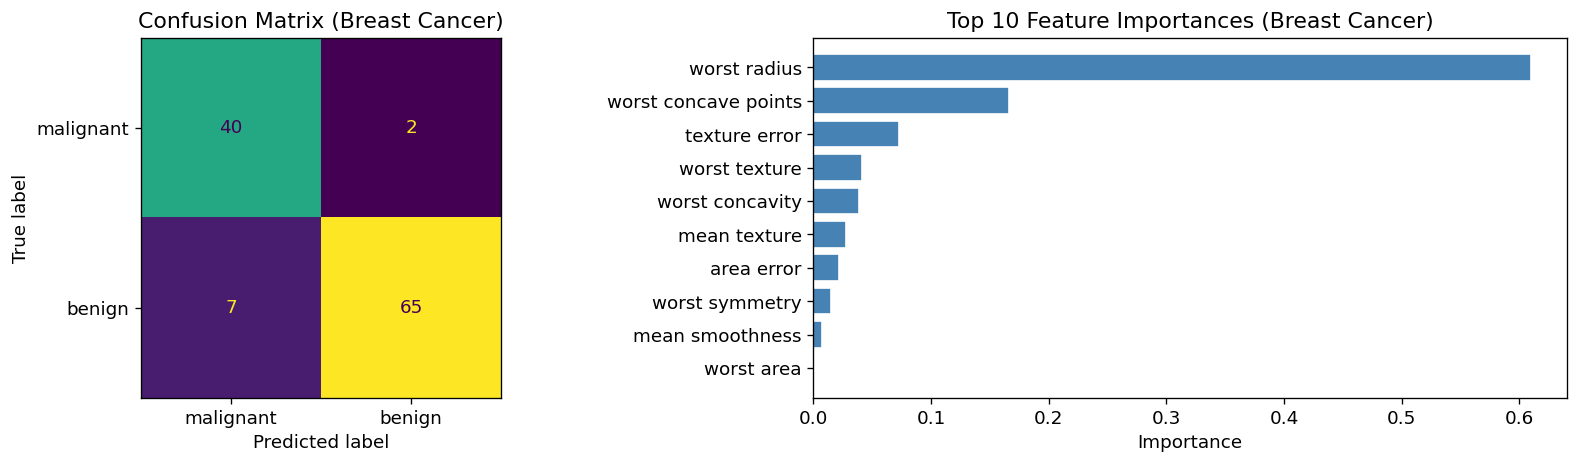

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import sys, os
sys.path.append(os.path.abspath("../../"))
from mlpackage.supervised_learning.decision_tree import DecisionTree

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


# ── Helper ────────────────────────────────────────────────────────────────────
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2, cmap="tab10")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="tab10", edgecolors="k", s=35)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")


# ── 1. Effect of max_depth ────────────────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 1 — Effect of max_depth (Moons)")
print("=" * 55)

X_moon, y_moon = make_moons(n_samples=300, noise=0.2, random_state=42)

depths = [1, 2, 5, 10]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, d in zip(axes, depths):
    clf = DecisionTree(max_depth=d, random_state=0)
    clf.fit(X_moon, y_moon)
    plot_decision_boundary(clf, X_moon, y_moon, ax,
        f"depth={d}  |  Acc={clf.score(X_moon, y_moon):.2%}")

plt.suptitle("Experiment 1 — Effect of max_depth (Moons)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


# ── 2. Entropy vs Gini ────────────────────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 2 — Entropy vs Gini Criterion")
print("=" * 55)

X_tr, X_te, y_tr, y_te = train_test_split(X_moon, y_moon, test_size=0.2, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, crit in zip(axes, ["entropy", "gini"]):
    clf = DecisionTree(criterion=crit, max_depth=5, random_state=0)
    clf.fit(X_tr, y_tr)
    plot_decision_boundary(clf, X_te, y_te, ax,
        f"{crit.capitalize()}  |  Test Acc={clf.score(X_te, y_te):.2%}")

plt.suptitle("Experiment 2 — Entropy vs Gini", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


# ── 3. Overfitting — Train vs Test Accuracy ───────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 3 — Overfitting Analysis")
print("=" * 55)

depth_range = range(1, 20)
train_accs, test_accs = [], []
for d in depth_range:
    clf = DecisionTree(max_depth=d, random_state=0)
    clf.fit(X_tr, y_tr)
    train_accs.append(clf.score(X_tr, y_tr))
    test_accs.append(clf.score(X_te, y_te))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(depth_range, train_accs, marker="o", markersize=4, label="Train Accuracy")
ax.plot(depth_range, test_accs,  marker="s", markersize=4, label="Test Accuracy")
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.set_title("Experiment 3 — Train vs Test Accuracy Across Depths")
ax.legend()
plt.tight_layout()
plt.show()
best_depth = list(depth_range)[np.argmax(test_accs)]
print(f"Best depth: {best_depth}  |  Test Accuracy: {max(test_accs):.2%}\n")


# ── 4. Feature Importance — Iris Dataset ─────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 4 — Iris Dataset & Feature Importances")
print("=" * 55)

iris = load_iris()
X_iris, y_iris = iris.data, iris.target
X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris)

clf_iris = DecisionTree(max_depth=5, random_state=0)
clf_iris.fit(X_tr_i, y_tr_i)
y_pred_iris = clf_iris.predict(X_te_i)

print(f"Test Accuracy : {clf_iris.score(X_te_i, y_te_i):.2%}\n")
print(classification_report(y_te_i, y_pred_iris, target_names=iris.target_names))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(confusion_matrix(y_te_i, y_pred_iris),
                       display_labels=iris.target_names).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix (Iris)")

axes[1].barh(iris.feature_names, clf_iris.feature_importances_,
             color="steelblue", edgecolor="white")
axes[1].set_xlabel("Importance")
axes[1].set_title("Feature Importances (Iris)")
plt.tight_layout()
plt.show()


# ── 5. Real Dataset — Breast Cancer ──────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 5 — Breast Cancer Dataset")
print("=" * 55)

data = load_breast_cancer()
X_b, y_b = data.data, data.target
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42, stratify=y_b)

clf_bc = DecisionTree(max_depth=5, random_state=0)
clf_bc.fit(X_tr_b, y_tr_b)
y_pred_bc = clf_bc.predict(X_te_b)

print(f"Test Accuracy : {clf_bc.score(X_te_b, y_te_b):.2%}\n")
print(classification_report(y_te_b, y_pred_bc, target_names=data.target_names))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ConfusionMatrixDisplay(confusion_matrix(y_te_b, y_pred_bc),
                       display_labels=data.target_names).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix (Breast Cancer)")

top_n = 10
top_idx = np.argsort(clf_bc.feature_importances_)[-top_n:]
axes[1].barh(np.array(data.feature_names)[top_idx],
             clf_bc.feature_importances_[top_idx],
             color="steelblue", edgecolor="white")
axes[1].set_xlabel("Importance")
axes[1].set_title(f"Top {top_n} Feature Importances (Breast Cancer)")
plt.tight_layout()
plt.show()